# Structural Estimation using DC-EGM for Education Level 1

## Dependencies, Packages & Roots

### Magics

In [1]:
%reload_ext autoreload
%autoreload 2

### Project Paths

In [2]:
from pathlib import Path
import sys
import importlib

# Change this depending on notebook location:
# 0 = notebook is 1 folder inside project root, e.g. dp_termpaper/edu1
# 1 = notebook is 2 folders inside project root, e.g. dp_termpaper/data/moments
# 2 = notebook is 3 folders inside project root
amount_of_levels = 0

DIR = Path.cwd().resolve().parents[amount_of_levels]

if str(DIR) not in sys.path:
    sys.path.insert(0, str(DIR))

import project_paths as pp
from project_imports import *

importlib.reload(pp)
jax.config.update("jax_enable_x64", True)

## Load Data 

In [3]:
###############################################################
#### Define which education level you want to estimate for ####
###############################################################

education_level_file = pp.MOMENTS_DIR / "moments_udd1.txt"
# education_level_file = pp.MOMENTS_DIR / "moments_udd2.txt"
# education_level_file = pp.MOMENTS_DIR / "moments_udd3.txt"

MORTALITY = pp.DATA_DIR / "mortality.xlsx"

beta0, beta1, beta2 = np.loadtxt(pp.FIRST_STAGE_RESULTS_DIR / "wage_params_udd1_ols.txt")

In [4]:
PARAM_FILE = pp.STRUCTURAL_RESULTS_DIR / "optimized_own_params_udd1.txt"
params = load_params_txt(PARAM_FILE)
# params

In [5]:
# Read CSV
df_edu = pd.read_csv(education_level_file)
# read mortality and discard seoncd and third column
df_mort = pd.read_excel(MORTALITY, sheet_name="DOD", usecols=[0, 3])

# 2) standardize colomn name and remove _FREQ_ column
# Iterate over DataFrames (if there are multiple DataFrames to process)
for data_frame in [df_edu]:
    # Rename ALDER → age
    if "ALDER" in data_frame.columns:
        data_frame.rename(columns={"ALDER": "age"}, inplace=True)
    # Remove _FREQ_-column if it exists
    # if "_FREQ_" in data_frame.columns:
    #     data_frame.drop(columns=["_FREQ_"], inplace=True)
# drop var_wage, skew_wage and pens
df_edu.drop(columns=["var_wage", "skew_wage", "pens"], inplace=True)
# df_edu

# ====================================================================================================================

# Structural Estimation

### Structure
1. setup_model
2. validate_exogenous
3. solve model
4. simulate data
5. convert/inspect simulated data
6. compute simulated moments
7. compare simulated moments to empirical moments
8. only then structural estimation

## Initiatal parameters - some are estimated above, the rest to be structuraly estimated

In [6]:
params_initial = {}
params_initial["interest_rate"] = 0.01
params_initial["income_shock_mean"] = 0.000 # income shock mean
params_initial["income_shock_std"] = 0.15721008127024574 # income shock scale
params_initial["taste_shock_scale"] = 1.0966242697158703 # taste shock scale

# discount factor
params_initial["discount_factor"] = 0.90535854

# parameters for the utility function
params_initial["rho"]=0.50092644 #0.76492381

# disutility of each hours choice
params_initial["gamma"]=jnp.array([0.82253966,1.5360604,1.93859858,1.25922689]) 

# wage parameters
params_initial["beta0"]=beta0
params_initial["beta1"]=beta1
params_initial["beta2"]=beta2

# Age component disutility
params_initial["kappa1"]=0.01531974
params_initial["kappa2"]=0.00216552

# transsition cost
params_initial["phi_entry"]=0.94614399
params_initial["phi_exit"]=0.94614399
params_initial["phi_switch"]=0.94614399

# mortality parameters
params_initial["alpha1"]=0.000417
params_initial["alpha2"]=0.099277

# bequest parameters
params_initial["b_scale"]=1.2133177
params_initial["xi"]=0.26926199

# labor market parameters
params_initial["eta_edu"]=0.43848

params=params_initial.copy()

## Options for model - Choices and states

In [7]:
n_periods = 55
labour_choices = np.arange(5) # 5 choices
alpha1, alpha2 = np.loadtxt(pp.STRUCTURAL_RESULTS_DIR/ "mortality_params.txt")

model_config = {
    "n_periods": n_periods,
    "choices": labour_choices, # 5 choices
    "n_quad_points": 5,
    "continuous_states": {
        "assets_end_of_period": np.linspace(0, 50, 20),
        "experience": jnp.linspace(0, 1, 5).astype(float) # 1 experince grid point, if experience can only go up by a year - more points if it is a fraction based on hours worked
        },
    "stochastic_states": {
        "survival": [0, 1],
    }
    }

model_specs = {
    "n_periods": n_periods,
    "labour_choices": labour_choices, # 5 choices
    "hours": jnp.array([0,250,750,1300,1900]), #list 
    "max_hours": 1500,
    "start_age": 30,
    "tax_threshold1": 0.480,
    "tax_threshold2": 5.698,
    "tax_base_rate": 0.38,
    "tax_top_rate": 0.5,
    "retirement_age": 67,
    "oap_base_amount":0.80328,
    "oap_max_supplement": 0.92940,
    "supp_threshold": 0.79300,
    "oap_threshold": 3.3592,
    "supp_reduction_rate": 0.309,
    "oap_reduction_rate": 0.3,
    "alpha1": alpha1, # independently estimated parameter for survival probability
    "alpha2": alpha2,  # independently estimated parameter for survival probability
    "max_init_experience": 5,
    "max_ret_period": 45, # Age 75
    "min_ret_period": 30, # Age 60
}
stochastic_states_transitions = {
    "survival": prob_survival
}

### Setup the model

In [8]:
model = dcegm.setup_model(
    model_config=model_config,
    model_specs=model_specs,
    utility_functions=utility_functions,
    utility_functions_final_period=final_period_utility,
    budget_constraint=budget_dcegm_initial,
    state_space_functions=create_state_space_function_dict(),
    stochastic_states_transitions=stochastic_states_transitions,
)

State specific choice set not provided. Assume all choices are available in every state.
Update function for state space not given. Assume states only change with an increase of the period and lagged choice.
Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  25
Model setup complete.



### Initial values for simulating. 

In [9]:
# Select number of individuals for simulation
#Debug level
# n_individuals = 10

# Optimal level
n_individuals = 100000

seed = 132
key = jax.random.PRNGKey(0)
n = n_individuals       

# hours mapping for simulation
hours_map = {0: 0, 1: 250, 2: 750, 3: 1300, 4: 1900}

#age for simulation
start_age = model_specs["start_age"] 

# distribution of initial choices
labels = jnp.array([0, 1, 2, 3, 4], dtype=jnp.int32)
probs  = jnp.array([0.259155, 0.118310, 0.108099, 0.108451, 0.405986])  # sums to 1.0

lagged_choice = jax.random.choice(
    key,
    a       = labels,
    shape   = (n,),
    p       = probs,
    replace = True
)

# set initial states for each individual
states_initial = {
    "period": jnp.zeros(n_individuals, dtype=jnp.int32),      # Every individual starts at period 0 (age 30)
    "lagged_choice": lagged_choice,  # Every individual starts with choice 3 (work fulltime)
    "experience": jnp.full(n_individuals, 1).astype(float),  # Every individual starts with 5 years of experience
    "survival": jnp.ones(n_individuals, dtype=jnp.int32), # Every individual starts with 1 (alive)
    "assets_begin_of_period": jnp.full(n_individuals, 0.505047) # Every individual starts with 59k wealth - to be adjusted based on the actual moments
}

# Estimation

In [10]:
keep_cols = ["hours_1", "hours_2", "hours_3","hours_4"]
share_cols = ["prob_work", "hours_0", "hours_1","hours_2","hours_3","hours_4", "work_work", "nowork_nowork"]

# Helper function for params into critical function
def theta_to_params(theta_array, base_params):
    p = base_params.copy()

    p["interest_rate"] = 0.01
    p["beta0"] = beta0
    p["beta1"] = beta1
    p["beta2"] = beta2

    p["income_shock_mean"] = theta_array[0]
    p["income_shock_std"] = theta_array[1]
    p["taste_shock_scale"] = theta_array[2]
    p["discount_factor"] = theta_array[3]
    p["rho"] = theta_array[4]
    p["gamma"] = jnp.array([
        theta_array[5],
        theta_array[6],
        theta_array[7],
        theta_array[8],
    ])
    p["kappa1"] = theta_array[9]
    p["kappa2"] = theta_array[10]

    p["phi_entry"] = theta_array[11]
    p["phi_exit"] = theta_array[12]
    p["phi_switch"] = theta_array[13]

    p["b_scale"] = theta_array[14]
    p["xi"] = theta_array[15]

    p.pop("phi", None)
    
    return p

# Helper function for determining variance in empirical moments
def compute_empirical_share_variances(df, share_cols, freq_col="_FREQ_"):
    df_var = df[["age", freq_col] + share_cols].copy()

    for col in share_cols:
        p = df_var[col]
        n = df_var[freq_col]
        df_var[col] = p * (1 - p) / n

    return df_var

base_params = params_initial.copy()
empirical_var = compute_empirical_share_variances(df_edu, share_cols)

In [11]:
def crit_func_scipy(theta_array):
    """
    MSM criterion function.

    For each parameter vector:
    1. Convert theta to model parameters.
    2. Solve the model.
    3. Simulate the solved model.
    4. Compute simulated moments.
    5. Compare simulated and empirical moments using inverse empirical
       sampling variances as diagonal weights.
    """

    # Penalize invalid parameter vectors early
    if not np.all(np.isfinite(theta_array)):
        return 1e20

    try:
        if (
            theta_array[11] < 0
            or theta_array[12] < 0
            or theta_array[13] < 0
        ):
            return 1e20

        # Convert theta vector into clean parameter dictionary
        p = theta_to_params(theta_array, base_params=base_params)

        # Validate exogenous parameters
        model.validate_exogenous(p)

        # Solve model at current parameter vector
        model_solved = model.solve(p)

        # Simulate model
        sim = model_solved.simulate(
            states_initial=states_initial,
            seed=seed,
        )

        # Compute simulated moments
        sim_moments = compute_simulation_moments(
            sim,
            start_age,
            hours_map,
        ).copy()

        emp_moments = df_edu.copy()

        # Keep age and selected moments
        sim_moments = sim_moments[["age"] + keep_cols]
        emp_moments = emp_moments[["age"] + keep_cols]
        emp_vars = empirical_var[["age"] + keep_cols]

        # Align simulated moments, empirical moments, and empirical variances by age
        merged = (
            emp_moments
            .merge(sim_moments, on="age", suffixes=("_emp", "_sim"))
            .merge(emp_vars, on="age")
        )

        crit_val = 0.0
        epsilon = 1e-8

        for col in keep_cols:
            diff = merged[f"{col}_sim"] - merged[f"{col}_emp"]
            var = merged[col]

            weight = 1.0 / (var + epsilon)
            crit_val += np.nansum(weight * diff**2)

        print("Crit value:", crit_val)

        return float(crit_val)

    except Exception as e:
        print("Criterion failed:", e)
        return 1e20

### Run the Estimation

In [12]:
flat_params = [
    params_initial["income_shock_mean"],
    params_initial["income_shock_std"],
    params_initial["taste_shock_scale"],
    params_initial["discount_factor"],
    params_initial["rho"],
    *params_initial["gamma"].tolist(),
    params_initial["kappa1"],
    params_initial["kappa2"],
    params_initial["phi_entry"],
    params_initial["phi_exit"],
    params_initial["phi_switch"],
    params_initial["b_scale"],
    params_initial["xi"],
]

initial_guess = np.array(flat_params, dtype=float)

result = minimize(
    crit_func_scipy,
    initial_guess,
    method="Nelder-Mead",
    options={"disp": True},
)

print("Optimization result:")
print(result)

Crit value: 282602.1160299296
Crit value: 282609.54992624646
Crit value: 283058.04930887505
Crit value: 327063.0144713974
Crit value: 310738.5246101774
Crit value: 285935.9422065882
Crit value: 279345.96085395326
Crit value: 277719.2934792079
Crit value: 280751.41673946695
Crit value: 286866.70072232455
Crit value: 279980.6776978685
Crit value: 274232.4243551966
Crit value: 279085.64054048015
Crit value: 279794.2890186552
Crit value: 276848.77012161026
Crit value: 283365.50224197906
Crit value: 282311.2394178398
Crit value: 251766.41213755158
Crit value: 243912.94564166007
Crit value: 276770.9294568306
Crit value: 281906.32683891495
Crit value: 264965.97007059556
Crit value: 263465.52084670146
Crit value: 261532.95377399286
Crit value: 259810.28204348515
Crit value: 257696.95921022465
Crit value: 255631.40485071606
Crit value: 266229.412070286
Crit value: 253575.61351542582
Crit value: 250337.84738457762
Crit value: 248407.980009626
Crit value: 246285.95658073795
Crit value: 243954.676

### Save the estimation results

In [16]:
# Rebuild optimized parameter dictionary using the same mapping
# as the criterion function.
params_hat = theta_to_params(result.x, base_params=base_params)

# Make absolutely sure legacy names are gone
params_hat.pop("sigma", None)
params_hat.pop("beta", None)
params_hat.pop("phi", None)

# Convert gamma from JAX array to NumPy array for cleaner saving    
params_hat["gamma"] = np.asarray(params_hat["gamma"])

# Save params dict as a .txt file
params_df = pd.DataFrame.from_dict(
    params_hat,
    orient="index",
    columns=["value"],
)

params_df.to_csv(
    pp.STRUCTURAL_RESULTS_DIR / "optimized_params_phi_udd1.txt",
    sep="\t",
)

params_df

,value
interest_rate,0.01
income_shock_mean,0.000522
income_shock_std,0.147742
taste_shock_scale,0.899376
discount_factor,0.867032
rho,0.335255
gamma,"[0.7352523115399857, 1.4130513559925229, 1.766..."
beta0,-6.896104
beta1,0.027168
beta2,-0.000177


## Plots

In [17]:
labels = {
    "avg_wealth": "Average Wealth",
    "hours_0": "Unemployed",
    "hours_1": "Below 10 hours",
    "hours_2": "10-20 hours",
    "hours_3": "20-30 hours",
    "hours_4": "Above 30 hours",
    "avg_hours": "Average Hours",
    "prob_work": "Employment Rate",
    "avg_wage": "Average Wage",
    "avg_experience": "Average Experience",
    "work_work": "Work to Work Transition Rate",
    "nowork_nowork": "No Work to No Work Transition Rate",
}

scales = {
    "avg_wealth": 100_000,
    "avg_wage": 100_000,
}

### Load params, solve model and simulate juts once

In [18]:
params = load_params_txt(pp.STRUCTURAL_RESULTS_DIR / "optimized_params_phi_udd1.txt")
# If you want to see Frederiks original parameters, load optimized_params_udd1.txt instead
params["gamma"] = jnp.asarray(params["gamma"])

model_solved = model.solve(params)
sim = model_solved.simulate(
    states_initial=states_initial,
    seed=seed,
)

Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\edu1_own_params\prob_work_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\edu1_own_params\hours_0_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\edu1_own_params\hours_1_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\edu1_own_params\hours_2_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\edu1_own_params\hours_3_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Results\plots\simulation\edu1_own_params\hours_4_over_age.png
Saved C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\4. Res

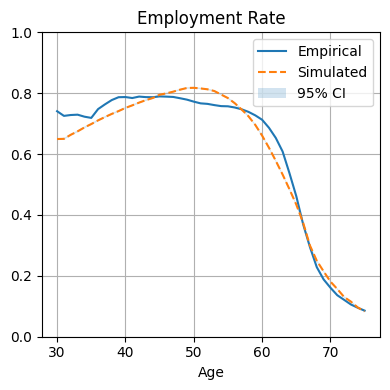

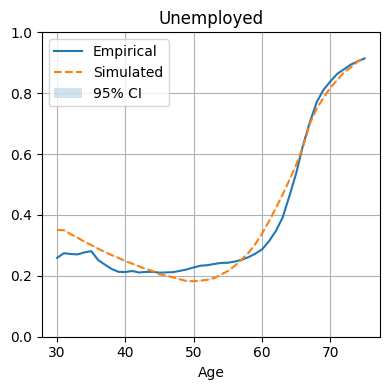

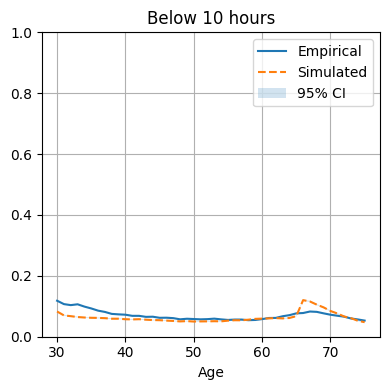

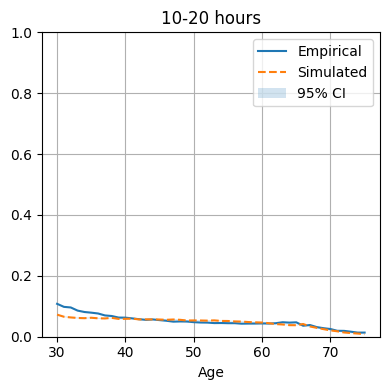

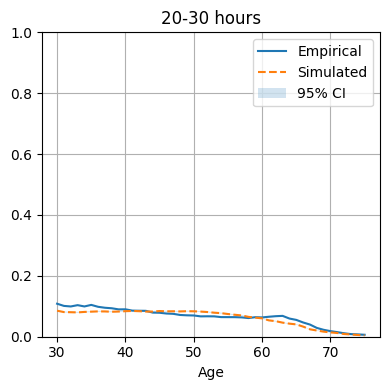

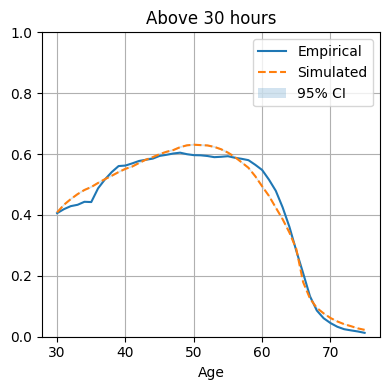

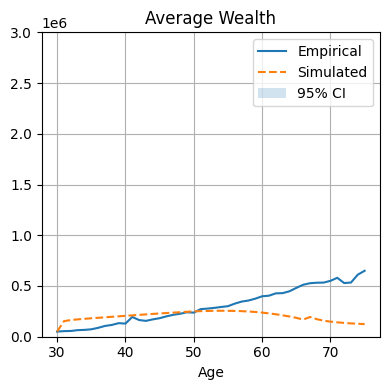

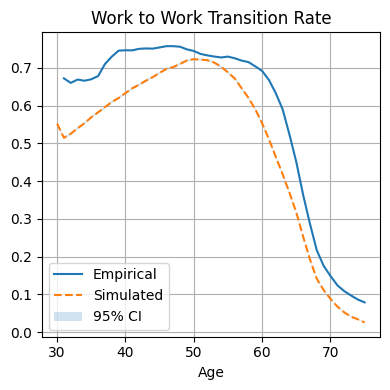

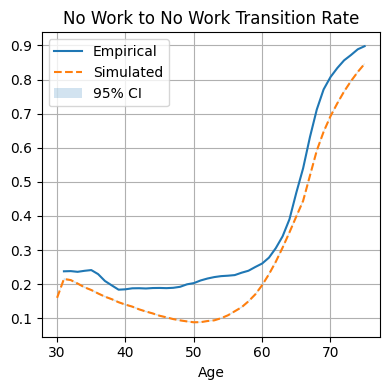

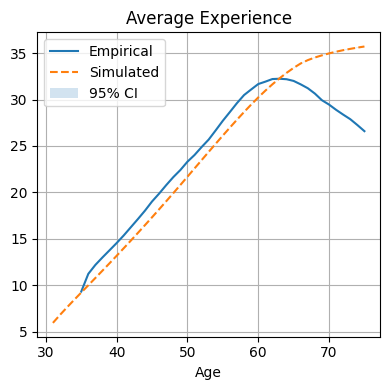

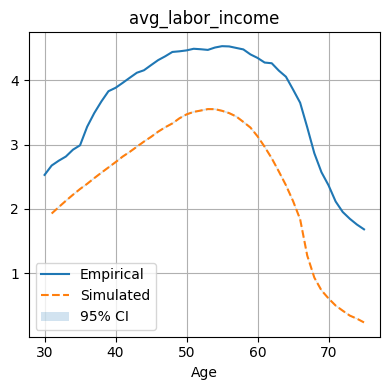

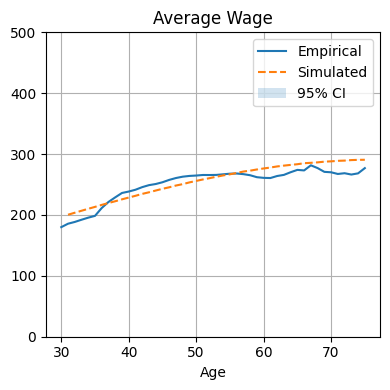

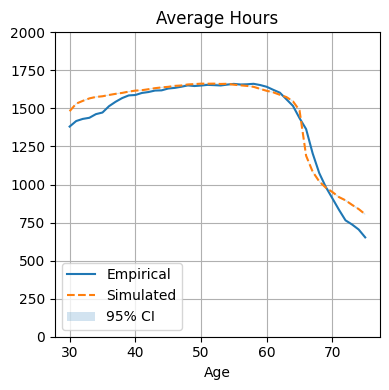

In [19]:
edu = df_edu.copy().loc[df_edu.age <= 75]       # empirical
moments_sim = compute_simulation_moments_with_ci(sim, start_age, hours_map)  # Call the function
# Ensure moments_sim.age is a pandas Series before filtering
moments_sim = moments_sim.loc[pd.Series(moments_sim.age) <= 75]  # Filter simulated + CIs
# scale avg_wealth by 100_000


# print plots
plot_empirical_vs_simulated_with_ci(
    edu = edu,
    moments_sim = moments_sim,
    out_subfolder="edu1_own_params",
    var_labels=labels,
    var_scales=scales,
    ylims={"avg_wealth": (0, 3_000_000), "avg_hours": (0, 2_000), "prob_work": (0, 1), "hours_0": (0, 1), "hours_1": (0, 1), "hours_2": (0, 1), "hours_3": (0, 1), "hours_4": (0, 1), "avg_wage": (0,500) },
)

# Conclusion

Adding in the two different switching costs actually improved the results on Average hours, 30+ hoursnd no-work to no.work transitionnd i believe on employment rate too.